# Ch06_08 — Actor-Critic (A2C): policy gradient + bootstrapping

REINFORCE uczy politykę na podstawie pełnych zwrotów $G_t$.  
Actor-Critic robi krok dalej: uczy jednocześnie:

- **Actor**: polityka $\pi_\theta(a|s)$
- **Critic**: wartość stanu $V_\phi(s)$

## Kluczowa intuicja (most z TD)

W TD(0) dla wartości mieliśmy błąd:

$
\delta_t = r_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$

W Actor-Critic **ten sam** \(\delta_t\) staje się estymatą advantage:

$
\hat A_t \approx \delta_t
$

i trafia do update aktora:

$
\theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(a_t|s_t)\, \hat A_t
$

a krytyk minimalizuje błąd wartości (np. MSE do targetu TD).

---

## A2C = „A3C bez asynchroniczności”

W praktyce często zbiera się rollout (np. 2048 kroków),
liczy advantage przez **GAE(λ)**:

$
\hat A_t^{\text{GAE}(\lambda)} = \sum_{l=0}^{\infty}(\gamma\lambda)^l \delta_{t+l}
$

i robi update aktora/krytyka na batchu.

To jest „bezpieczny” krok przed PPO:
- A2C: policy gradient na advantage (bez clip),
- PPO: to samo, ale z *clippingiem* ratio.

---

## W tym notebooku

- Środowisko: **Pendulum-v1** (ciągłe)
- Algorytm: **A2C (on-policy)** + GAE


In [1]:
# !pip install gymnasium
import numpy as np
import matplotlib.pyplot as plt
import torch

from policy_based_continuous import train_a2c


## Konfiguracja

Parametry, które najbardziej wpływają:
- `rollout_steps`: ile kroków zbieramy przed update (większe = stabilniej, ale wolniej reaguje),
- `gae_lambda`: bliżej 1.0 = bardziej MC-like, bliżej 0 = bardziej TD(0)-like,
- learning rate aktora / krytyka.


In [2]:
cfg = dict(
    env_id="Pendulum-v1",
    seed=0,
    total_steps=80_000,
    rollout_steps=2048,
    update_epochs=1,       # A2C zwykle 1 (PPO robi wiele epok)
    minibatch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    actor_lr=3e-4,
    critic_lr=1e-3,
    ent_coef=0.0,          # można podbić np. 0.001
    hidden_sizes=(64, 64),
)

ac, log = train_a2c(**cfg)
log.steps[:3], log.avg_return[:3]


/home/piotr/anaconda3/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


([2048, 12288, 22528],
 [-5.569848537445068, -6.72822904586792, -5.337810516357422])

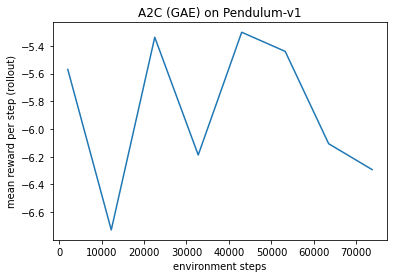

In [3]:
plt.figure()
plt.plot(log.steps, log.avg_return)
plt.xlabel("environment steps")
plt.ylabel("mean reward per step (rollout)")
plt.title("A2C (GAE) on Pendulum-v1")
plt.show()


## Co dalej?

A2C robi już „sensowne” kroki w kierunku nowoczesnych metod,
ale nadal może mieć problem z:

- zbyt dużymi update’ami polityki (niestabilność),
- „cofnięciem” jakości po złym batchu.

PPO naprawia to przez ograniczenie zmiany polityki w jednym kroku (clipping lub KL).
